In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_raw = pd.read_csv('../data/raw/PRSA_data_2010.1.1-2014.12.31.csv')

In [3]:
def data_prep(df_raw: pd.DataFrame) -> pd.DataFrame:
	df_local = df_raw.drop(columns = 'No').copy()	
	
	df_local.rename(columns = {'pm2.5': 'pm2_5'}, inplace = True)

	cols = [x.lower() for x in df_local.columns]
	df_local.columns = cols
	
	# astype str in the following features
	df_local['year_str'] = df_local.year.astype(str)
	df_local['month_str'] = df_local.month.astype(str)
	df_local['day_str'] = df_local.day.astype(str)
	df_local['hour_str'] = df_local.hour.astype(str)


	df_local['month_str'] = df_local.month_str.str.pad(side = 'left', width = 2, fillchar = '0')
	df_local['day_str'] = df_local.day_str.str.pad(side = 'left', width = 2, fillchar = '0')
	
	df_local['date'] = df_local.year_str + '-' + df_local.month_str + '-' + df_local.day_str
	df_local['period'] = df_local.year_str + df_local.month_str 

	return df_local.copy()

In [49]:
df = data_prep(df_raw)

In [124]:
df.describe()

,year,month,day,hour,pm2_5,dewp,temp,pres,iws,is,ir
count,43824.000000,43824.000000,43824.000000,43824.000000,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,2012.000000,6.523549,15.727820,11.500000,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,1.413842,3.448572,8.799425,6.922266,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,2010.000000,1.000000,1.000000,0.000000,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,2011.000000,4.000000,8.000000,5.750000,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,2012.000000,7.000000,16.000000,11.500000,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,2013.000000,10.000000,23.000000,17.250000,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,2014.000000,12.000000,31.000000,23.000000,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


In [82]:
df.isnull().sum()

year         0
month        0
day          0
hour         0
pm2_5     2067
dewp         0
temp         0
pres         0
cbwd         0
iws          0
is           0
ir           0
date         0
period       0
dtype: int64

In [126]:
df_pm_null = df[df.pm2_5.isnull()]

In [127]:
df_pm_null.describe()

,year,month,day,hour,pm2_5,dewp,temp,pres,iws,is,ir
count,2067.000000,2067.000000,2067.000000,2067.000000,0.0,2067.000000,2067.000000,2067.000000,2067.000000,2067.0,2067.000000
mean,2011.135946,6.721335,16.582487,11.453314,NaN,3.172230,13.397194,1016.543783,24.341500,0.0,0.195936
std,1.063975,3.327515,9.035230,6.871390,NaN,14.365588,12.627719,9.600510,57.390592,0.0,1.368934
min,2010.000000,1.000000,1.000000,0.000000,NaN,-27.000000,-18.000000,996.000000,0.450000,0.0,0.000000
25%,2010.000000,4.000000,8.000000,6.000000,NaN,-8.000000,4.000000,1009.000000,1.790000,0.0,0.000000
50%,2011.000000,8.000000,19.000000,11.000000,NaN,6.000000,16.000000,1016.000000,5.370000,0.0,0.000000
75%,2012.000000,9.000000,24.000000,17.000000,NaN,15.000000,23.000000,1023.000000,21.460000,0.0,0.000000
max,2014.000000,12.000000,31.000000,23.000000,NaN,27.000000,36.000000,1041.000000,585.600000,0.0,21.000000


Text(0, 0.5, 'total null count')

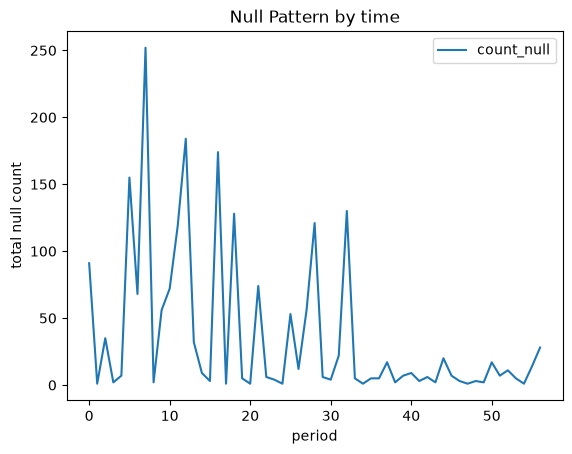

In [98]:
df_pm_null.groupby(['period']).agg(count_null = ('pm2_5', 'size')).reset_index().plot()
plt.title('Null Pattern by time')
plt.xlabel('period')
plt.ylabel('total null count')


In [100]:
df_pm_null.year.value_counts()

year
2011    728
2010    669
2012    489
2014     99
2013     82
Name: count, dtype: int64

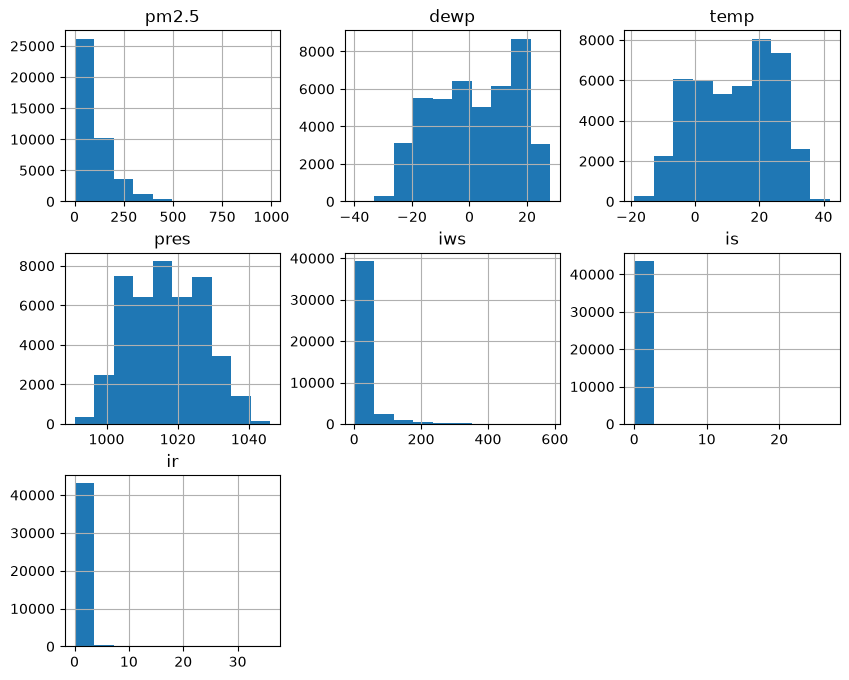

In [45]:
df.hist(figsize = (10, 8))
plt.show()

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    43824 non-null  int64  
 1   month   43824 non-null  int64  
 2   day     43824 non-null  int64  
 3   hour    43824 non-null  int64  
 4   pm2.5   41757 non-null  float64
 5   dewp    43824 non-null  int64  
 6   temp    43824 non-null  float64
 7   pres    43824 non-null  float64
 8   cbwd    43824 non-null  str    
 9   iws     43824 non-null  float64
 10  is      43824 non-null  int64  
 11  ir      43824 non-null  int64  
dtypes: float64(4), int64(7), str(1)
memory usage: 4.0 MB


In [101]:
df.cbwd.value_counts()

cbwd
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64

<Axes: xlabel='hour', ylabel='pm2_5'>

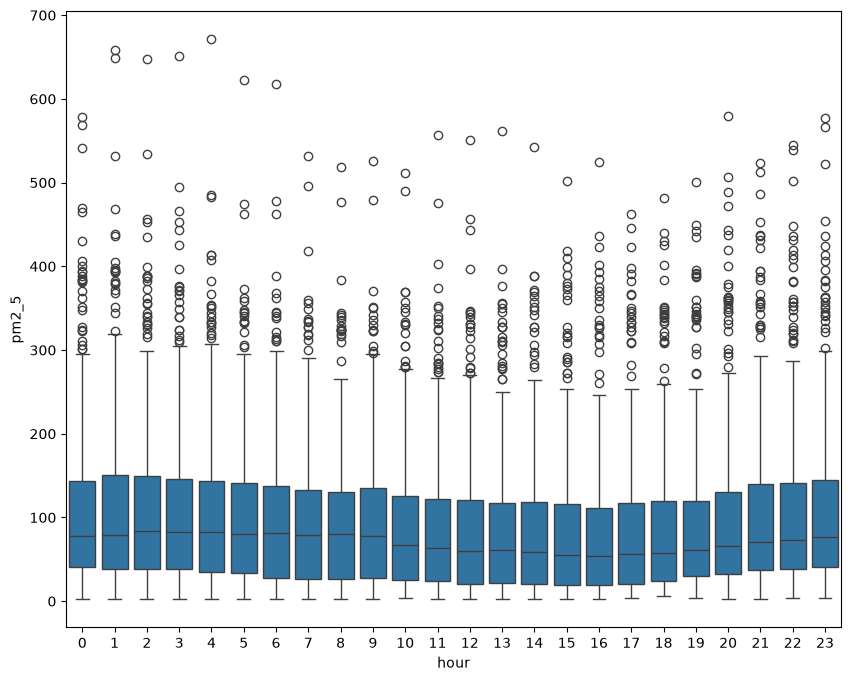

In [105]:
plt.figure(figsize = (10, 8))
sns.boxplot(data = df[(df.year == '2014')],
						x = 'hour',
						y = 'pm2_5')
				

In [5]:
df.pm2_5.describe()

count    41757.000000
mean        98.613215
std         92.050387
min          0.000000
25%         29.000000
50%         72.000000
75%        137.000000
max        994.000000
Name: pm2_5, dtype: float64

In [50]:
period_of_day = [0, 6, 12, 18, 23]
labels = ['d', 'm', 'a', 'n']

df['period_day'] = pd.cut(x = df.hour,
    											bins = period_of_day,
                          labels = labels,
													include_lowest = True)

In [17]:
df

,year,month,day,hour,pm2_5,dewp,temp,pres,cbwd,iws,is,ir,year_str,month_str,day_str,hour_str,date,period,period_day
0,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0,2010,01,01,0,2010-01-01,201001,d
1,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0,2010,01,01,1,2010-01-01,201001,d
2,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0,2010,01,01,2,2010-01-01,201001,d
3,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0,2010,01,01,3,2010-01-01,201001,d
4,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0,2010,01,01,4,2010-01-01,201001,d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43819,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0,2014,12,31,19,2014-12-31,201412,n
43820,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0,2014,12,31,20,2014-12-31,201412,n
43821,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0,2014,12,31,21,2014-12-31,201412,n
43822,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0,2014,12,31,22,2014-12-31,201412,n


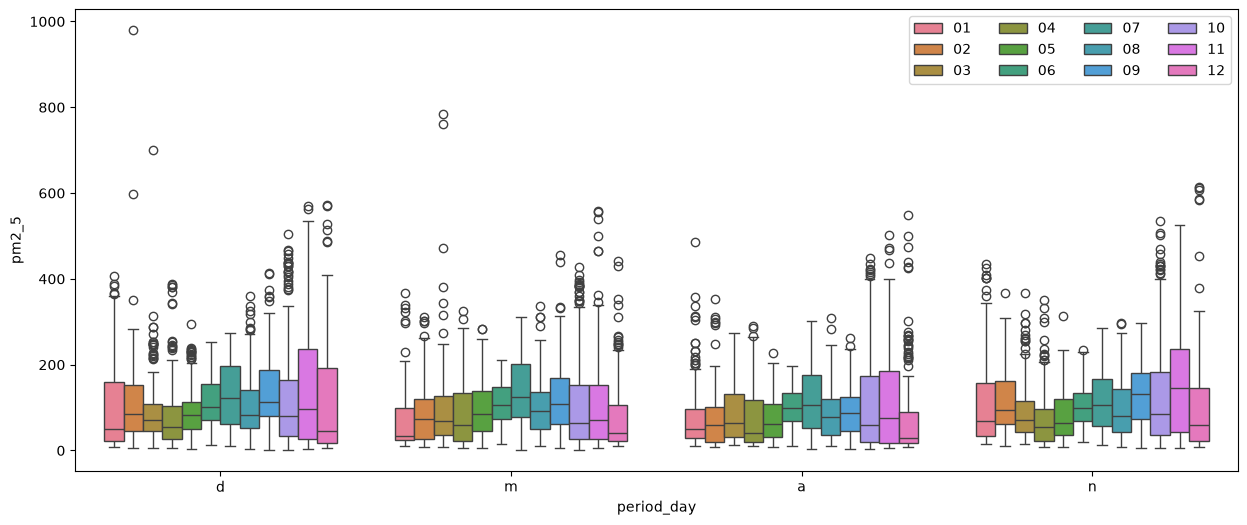

In [36]:
f = df.year == 2010
plt.figure(figsize = (15, 6))
sns.boxplot(
		data = df[f],
    x = 'period_day',
    y = 'pm2_5',
    hue = 'month_str'
)
plt.legend(ncols = 4)

In [61]:
tendency_analysis_df = df[df.year.isin([2012,2013])].groupby(['date', 'period_day']).pm2_5.mean().reset_index()
tendency_analysis = tendency_analysis_df.pm2_5.ewm(span = 15, adjust = False).mean()

<Axes: >

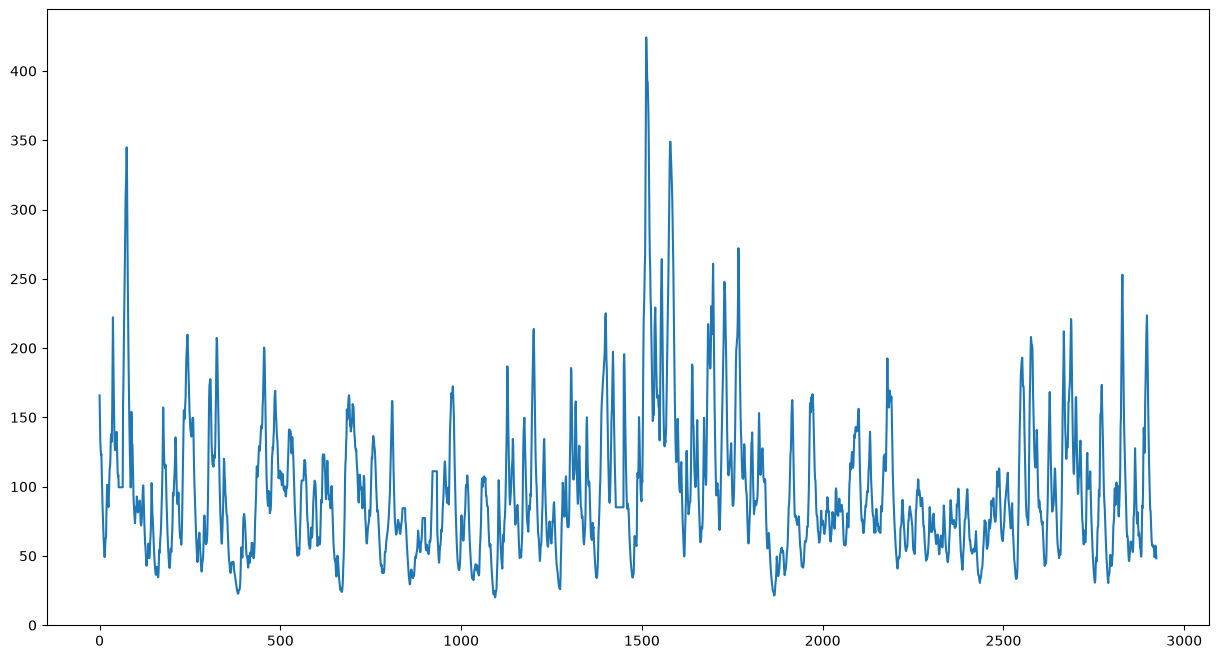

In [62]:
tendency_analysis.plot(figsize=(15, 8))

In [63]:
df.head()

,year,month,day,hour,pm2_5,dewp,temp,pres,cbwd,iws,is,ir,year_str,month_str,day_str,hour_str,date,period,period_day
0,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0,2010,01,01,0,2010-01-01,201001,d
1,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0,2010,01,01,1,2010-01-01,201001,d
2,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0,2010,01,01,2,2010-01-01,201001,d
3,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0,2010,01,01,3,2010-01-01,201001,d
4,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0,2010,01,01,4,2010-01-01,201001,d


In [66]:
mean_period = df.groupby(['period', 'period_day']).pm2_5.mean().reset_index()

<Axes: xlabel='period_day', ylabel='pm2_5'>

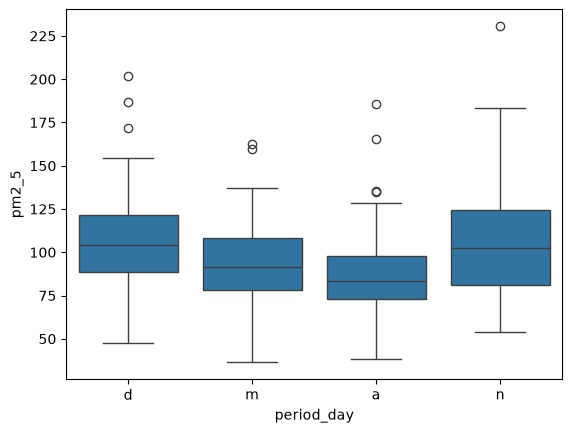

In [74]:
#mean_period[mean_period['period_day'] == 'd'].plot()

sns.boxplot(data = mean_period,
            x = 'period_day',
            y = 'pm2_5',
)

<Axes: >

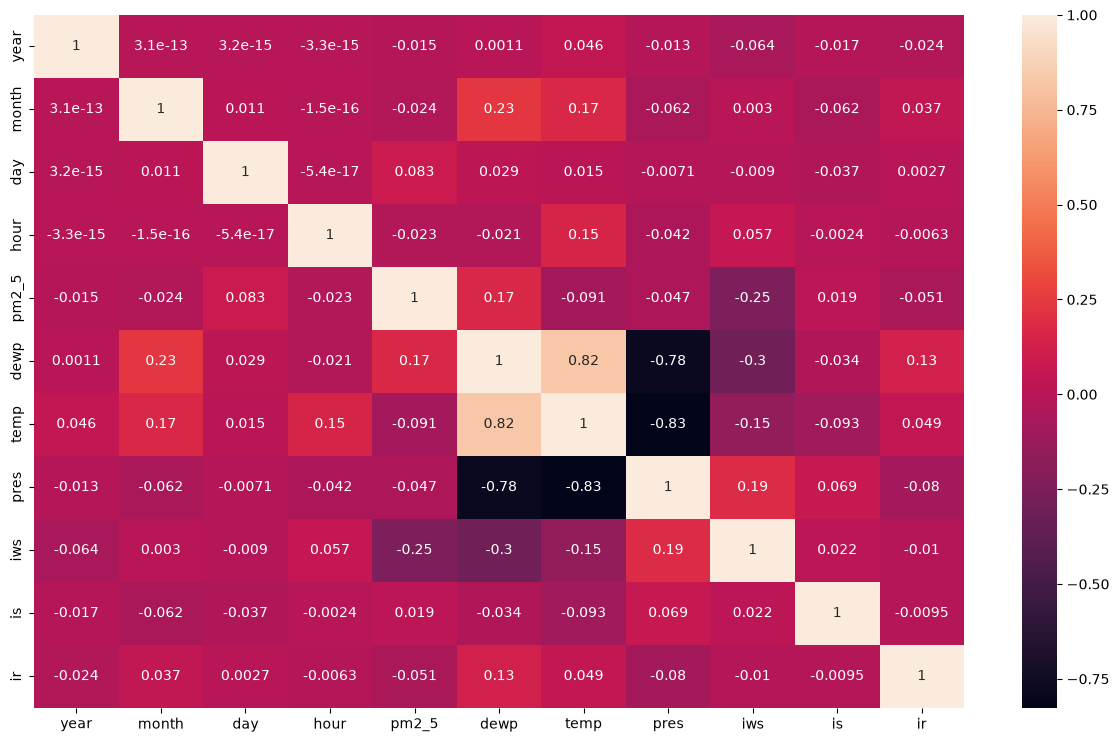

In [76]:
df_corr = df.corr(method='pearson', numeric_only = True)
plt.figure(figsize = (15, 9))
sns.heatmap(data = df_corr, annot = True)